# COCO pré-treinado vs. YOLOv11 customizado

Este notebook compara o **YOLOv11 pré-treinado em COCO** com o **YOLOv11 treinado no dataset customizado** do Urban Disaster Monitor. 

- No COCO, civilian e rescuer são mapeados para a classe "person"
- No dataset do Urban Disaster Monitor, as classes são distintas. 

Aqui avaliamos os dois modelos nas mesmas imagens (com labels mapeadas para IDs COCO) e comparamos Precision, Recall, mAP@0.5 e mAP@0.5–0.95.

---
**Projeto:** [Urban Disaster Monitor](https://github.com/MariaCarolinass/urban-disaster-monitor) · **Autores:** Carolina Soares, João Galdino

## 1. Preparar dataset para avaliação COCO

O dataset do Urban Disaster Monitor tem 6 classes (civilian, rescuer, cat, dog, horse, cow). Para avaliar o modelo **pré-treinado em COCO**, mapeamos as anotações para os IDs do COCO: 

- civilian e rescuer → 0 (person)
- cat → 15
- dog → 16
- horse → 17
- cow → 19

Assim o YOLO pré-treinado vê apenas "person" + animais, em pé de igualdade com a avaliação do modelo customizado.

In [ ]:
import os
import shutil
from pathlib import Path

# Tenha o dataset no formato YOLO em `dataset/` (ou ajuste `INPUT_DATASET`)
INPUT_DATASET = "../dataset"
OUTPUT_DATASET = "../dataset_filtered"

# Mapeamento: classe_original_dataset -> ID do COCO
class_coco_id_mapping = {
    0: 15,  # cat (original) -> 15 (COCO ID para cat)
    1: 0,   # person/civilian (original) -> 0 (COCO ID para person)
    2: 19,  # cow (original) -> 19 (COCO ID para cow)
    3: 16,  # dog (original) -> 16 (COCO ID para dog)
    4: 17,  # horse (original) -> 17 (COCO ID para horse)
    5: 0    # person/rescuer (original) -> 0 (COCO ID para person)
}

def filter_annotations(input_dir, output_dir, split='train'):
    """Filtra e reindexa classes para IDs do COCO"""
    labels_in = Path(input_dir) / split / 'labels'
    labels_out = Path(output_dir) / split / 'labels'
    images_in = Path(input_dir) / split / 'images'
    images_out = Path(output_dir) / split / 'images'

    # Limpa o diretório de saída se já existir
    if labels_out.exists():
        shutil.rmtree(labels_out)
    if images_out.exists():
        shutil.rmtree(images_out)

    labels_out.mkdir(parents=True, exist_ok=True)
    images_out.mkdir(parents=True, exist_ok=True)

    processed = 0
    skipped = 0

    for label_file in labels_in.glob('*.txt'):
        new_lines = []

        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue

                try:
                    old_class = int(parts[0])

                    # Remapeia para ID do COCO se a classe estiver no mapping
                    if old_class in class_coco_id_mapping:
                        coco_class_id = class_coco_id_mapping[old_class]
                        # Mantém o resto da linha (coordenadas)
                        new_lines.append(f"{coco_class_id} {' '.join(parts[1:])}\n")
                except (ValueError, IndexError):
                    print(f"Linha malformada em {label_file.name}: {line}")
                    continue

        # Só copia se houver pelo menos uma anotação válida
        if new_lines:
            # Salva o arquivo de label
            with open(labels_out / label_file.name, 'w') as f:
                f.writelines(new_lines)

            # Copia a imagem correspondente
            image_copied = False
            for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                image_path = images_in / (label_file.stem + ext)
                if image_path.exists():
                    shutil.copy(image_path, images_out / image_path.name)
                    processed += 1
                    image_copied = True
                    break

            if not image_copied:
                print(f"Aviso: Label {label_file.name} sem imagem correspondente")
        else:
            skipped += 1

    print(f"  {split}: {processed} imagens processadas, {skipped} ignoradas (sem classes v\u00e1lidas)")

# Remover cache antigo (se existir)
cache_files = [
    f"{OUTPUT_DATASET}/train/labels.cache",
    f"{OUTPUT_DATASET}/valid/labels.cache",
    f"{OUTPUT_DATASET}/test/labels.cache",
]
for cache_file in cache_files:
    if os.path.exists(cache_file):
        os.remove(cache_file)
        print(f"Cache removido: {cache_file}")

input_dataset = INPUT_DATASET
output_dataset = OUTPUT_DATASET

if not Path(input_dataset).exists():
    print("Aviso: pasta do dataset não encontrada. Baixe o dataset (ex.: notebook training-yolo-dataset) e ajuste INPUT_DATASET.")

print("\nFiltrando dataset com IDs do COCO...")
for split in ['train', 'valid', 'test']:
    if os.path.exists(f"{input_dataset}/{split}"):
        filter_annotations(input_dataset, output_dataset, split)

print("\nDataset filtrado criado!")
print("\nVerificando uma label de exemplo...")

# Verifica uma label de exemplo
valid_labels_dir = Path(output_dataset) / "valid" / "labels"
valid_labels = list(valid_labels_dir.glob("*.txt")) if valid_labels_dir.exists() else []
if valid_labels:
    with open(valid_labels[0], 'r') as f:
        print(f"\nConte\u00fado de {valid_labels[0].name}:")
        print(f.read())
else:
    print("ERRO: Nenhuma label foi criada no diret\u00f3rio valid!")


Filtrando dataset com IDs do COCO...
  train: 2674 imagens processadas, 0 ignoradas (sem classes válidas)
  valid: 383 imagens processadas, 0 ignoradas (sem classes válidas)
  test: 183 imagens processadas, 0 ignoradas (sem classes válidas)

Dataset filtrado criado!

Verificando uma label de exemplo...

Conteúdo de image_5b495164fcad4f28b5a43c7bd2e7c4b4_png.rf.24604ff8be7d559b586cfdc67eba4c8a.txt:
17 0.72109375 0.43984375 0.20078125 0.14921875
17 0.53984375 0.37109375 0.1671875 0.08125
17 0.44765625 0.50859375 0.3515625 0.221875
17 0.22265625 0.5 0.26640625 0.19140625
17 0.2609375 0.42578125 0.11171875 0.05546875



Crie o `data.yaml` do dataset filtrado (classes no formato COCO).

In [22]:
# data.yaml para o dataset filtrado (avaliação nas classes COCO usadas)
data_yaml_path = Path(output_dataset) / "data_filtered.yaml"
data_yaml_path.parent.mkdir(parents=True, exist_ok=True)
content = f"""train: ../train/images
val: ../valid/images
test: ../test/images

nc: 20 # Max COCO ID + 1 (Cow is 19)
names: [
    'person', 'null', 'null', 'null', 'null', 'null', 'null', 'null', 'null', 'null',
    'null', 'null', 'null', 'null', 'null', 'cat', 'dog', 'horse', 'null', 'cow'
]
"""
data_yaml_path.write_text(content)
print(f"Criado: {data_yaml_path}")

Criado: ../dataset_filtered/data_filtered.yaml


## 2. Avaliar modelo pré-treinado em COCO e customizado

Instale a biblioteca Ultralytics.

In [10]:
!pip install ultralytics --quiet

Rode a validação do YOLOv11 pré-treinado no dataset filtrado.

In [25]:
# classes: 0=person, 15=cat, 16=dog, 17=horse, 19=cow
data_yaml = output_dataset + "/data_filtered.yaml"
!yolo detect val model=yolo11m.pt data={data_yaml} imgsz=640 classes=0,15,16,17,19

100%|██████████████████████████████████████| 38.8M/38.8M [00:02<00:00, 14.9MB/s]
Ultralytics 8.3.162 🚀 Python-3.12.3 torch-2.7.1+cu126 CPU (13th Gen Intel Core(TM) i7-1355U)
YOLO11m summary (fused): 125 layers, 20,091,712 parameters, 0 gradients, 68.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5601.3±1560.7 MB/s, size: 70.9 KB)
val: Scanning /home/carol/urban-disaster-monitor/dataset_filtered/valid/labels.c
/home/carol/urban-disaster-monitor/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all        383       1383      0.868      0.707      0.803      0.422
                person        259        815      0.875      0.698      0.769      0.337
                   cat         35        123      0.953      0.6

Rode a validação do modelo **customizado** no dataset **original**.

In [ ]:
data_yaml = input_dataset + "/data.yaml"
!yolo detect val model=../models/yolov11m/best.pt data={data_yaml} imgsz=640

Ultralytics 8.3.162 🚀 Python-3.12.3 torch-2.7.1+cu126 CPU (13th Gen Intel Core(TM) i7-1355U)
YOLO11m summary (fused): 125 layers, 20,034,658 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4339.1±1444.3 MB/s, size: 65.5 KB)
val: Scanning /home/carol/urban-disaster-monitor/dataset/valid/labels... 383 ima
val: New cache created: /home/carol/urban-disaster-monitor/dataset/valid/labels.cache
/home/carol/urban-disaster-monitor/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all        383       1383      0.874      0.772      0.861      0.516
                   cat         35        123      0.909      0.789      0.883      0.545
              civilian        211        633      0.875    

## 3. Comparação Custom vs. COCO pré-treinado

O modelo **customizado** supera o **pré-treinado em COCO** em Recall, mAP@0.5 e mAP@0.5–0.95, com Precision equivalente. Isso mostra a vantagem do treino específico de domínio para cenários de desastre, em que a distinção entre civis e socorristas e a detecção em cenas de inundação são essenciais. 

O gráfico abaixo resume os valores de referência.

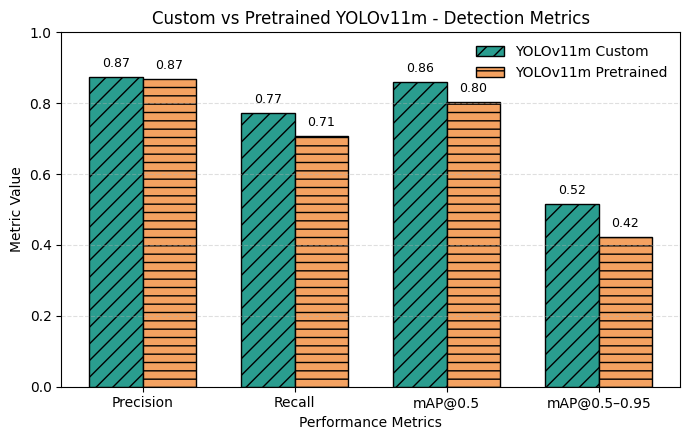

In [28]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision", "Recall", "mAP@0.5", "mAP@0.5–0.95"]
yolo_custom = [0.874, 0.772, 0.861, 0.516]
yolo_pretrained = [0.868, 0.707, 0.803, 0.422]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))

bars1 = ax.bar(x - width / 2, yolo_custom, width, label="YOLOv11m Custom", color="#2A9D8F", edgecolor="black", hatch="//")
bars2 = ax.bar(x + width / 2, yolo_pretrained, width, label="YOLOv11m Pretrained", color="#F4A261", edgecolor="black", hatch="--")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Metric Value")
ax.set_xlabel("Performance Metrics")
ax.set_title("Custom vs Pretrained YOLOv11m - Detection Metrics")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()